# Sign Language Multiclass Classification with PyTorch

This notebook adapts the course section **Multiclass Classification with PyTorch (Addendum)** to our project dataset. The structure is intentionally close to the addendum: dataset, dataloaders, network, cross-entropy loss, minibatch training, accuracy, and model saving/loading.


In [1]:
import os
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

from Dataset import SignLanguageDataset
from model import LinearNet, Net

random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## 1. Load labels and inspect the dataset

The label file has no header. Each row contains the class label and the image filename.

In [2]:
PROJECT_ROOT = Path(".")
DATA_DIR = PROJECT_ROOT / "sign_lang_train" / "sign_lang_train"
LABELS_FILE = DATA_DIR / "labels.csv"

assert DATA_DIR.exists(), f"Dataset directory not found: {DATA_DIR.resolve()}"
assert LABELS_FILE.exists(), f"Labels file not found: {LABELS_FILE.resolve()}"

df = pd.read_csv(LABELS_FILE, header=None, names=["label", "image_path"])
df["label"] = df["label"].astype(str)

print(df.head())
print("Number of images:", len(df))
print("Number of classes:", df["label"].nunique())

  label            image_path
0     l  EOOYFWMXLNQZDRDC.jpg
1     l  FUUDFATMEYSFGFAV.jpg
2     l  LPMYBDJUNIHWWNYQ.jpg
3     l  AWDPGQDXTGBMXDMV.jpg
4     l  CTIMIWDGHBMIAIZJ.jpg
Number of images: 9680
Number of classes: 36


In [3]:
labels = sorted(df["label"].unique().tolist())
label_to_idx = {label: idx for idx, label in enumerate(labels)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

print(labels)
print(label_to_idx)

counts = df["label"].value_counts().sort_index()
print(counts)

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
{'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9, 'a': 10, 'b': 11, 'c': 12, 'd': 13, 'e': 14, 'f': 15, 'g': 16, 'h': 17, 'i': 18, 'j': 19, 'k': 20, 'l': 21, 'm': 22, 'n': 23, 'o': 24, 'p': 25, 'q': 26, 'r': 27, 's': 28, 't': 29, 'u': 30, 'v': 31, 'w': 32, 'x': 33, 'y': 34, 'z': 35}
label
0    560
1    112
2    112
3    112
4    560
5    112
6    560
7    112
8    168
9    560
a    112
b    280
c    560
d    168
e    112
f    112
g    560
h    112
i    280
j    280
k    168
l    560
m    112
n    112
o    112
p    560
q    112
r    112
s    280
t    104
u    560
v    280
w    112
x    112
y    280
z    560
Name: count, dtype: int64


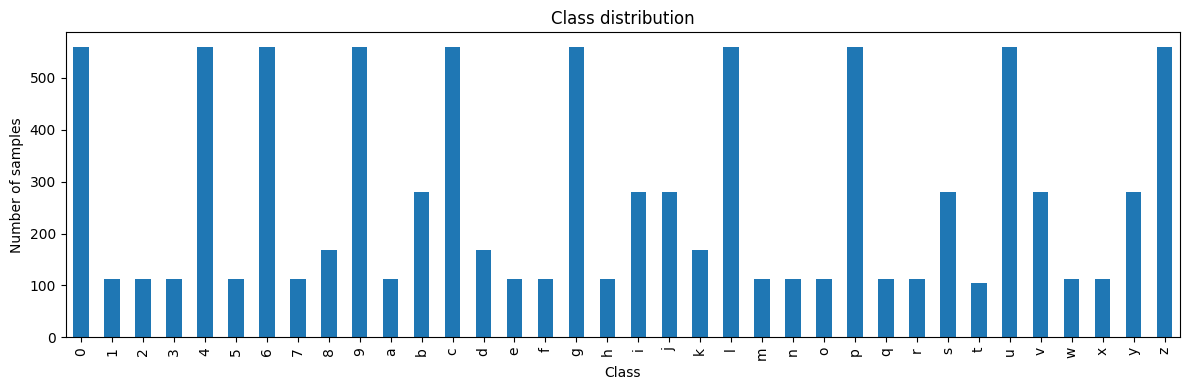

In [4]:
plt.figure(figsize=(12, 4))
counts.plot(kind="bar")
plt.title("Class distribution")
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.tight_layout()
plt.show()

## 2. Hyperparameters

Compared to the MNIST addendum, the important adaptations are `INPUT_SIZE = 64 * 64` and `OUTPUT_SIZE = 36`.

In [5]:
# Hyperparameters adapted from the multiclass PyTorch addendum
LEARNING_RATE = 0.001
MOMENTUM = 0.9
NUM_EPOCHS = 100
HIDDEN_SIZE = 256
TRAIN_BATCH_SIZE = 64
TEST_BATCH_SIZE = 64

IMAGE_SIZE = 64
INPUT_SIZE = IMAGE_SIZE * IMAGE_SIZE  # 64x64 grayscale images -> 4096 features
OUTPUT_SIZE = len(labels)             # 36 classes

print("INPUT_SIZE:", INPUT_SIZE)
print("OUTPUT_SIZE:", OUTPUT_SIZE)

INPUT_SIZE: 4096
OUTPUT_SIZE: 36


## 3. Transforms

The MLP receives flattened tensors. The images are resized, converted to tensors, and normalized. Light random rotation is only used for the training set.

In [6]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

## 4. Stratified train/validation/test split

The classes are imbalanced, so we use a stratified split instead of a purely random split.

In [7]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=random_seed,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=random_seed,
    stratify=temp_df["label"]
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 6776
Validation: 1452
Test: 1452


## 5. Dataset objects and DataLoaders

This corresponds to the DataLoader part of the course addendum. The only difference is that we use our own dataset class instead of `datasets.MNIST`.

In [8]:
train_dataset = SignLanguageDataset(train_df, DATA_DIR, transform=train_transform, label_to_idx=label_to_idx)
val_dataset = SignLanguageDataset(val_df, DATA_DIR, transform=eval_transform, label_to_idx=label_to_idx)
test_dataset = SignLanguageDataset(test_df, DATA_DIR, transform=eval_transform, label_to_idx=label_to_idx)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=TEST_BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=TEST_BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

num_train_batches = len(train_loader)
num_val_batches = len(val_loader)
num_test_batches = len(test_loader)

print(f"num_train_batches: {num_train_batches}")
print(f"num_val_batches: {num_val_batches}")
print(f"num_test_batches: {num_test_batches}")

num_train_batches: 105
num_val_batches: 23
num_test_batches: 23


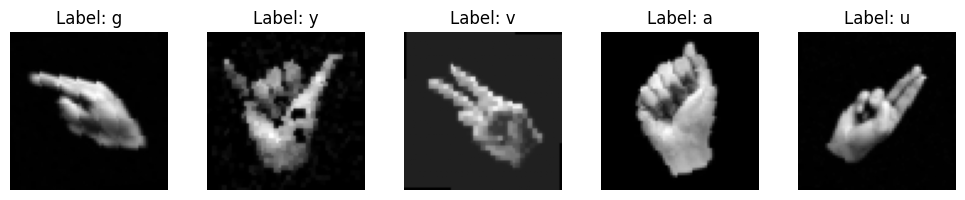

In [9]:
# View sample data
fig, ax = plt.subplots(1, 5, figsize=(10, 2))
for i in range(5):
    image, label_idx = train_dataset[i]
    ax[i].imshow(image.squeeze(0), cmap="gray")
    ax[i].set_title(f"Label: {idx_to_label[int(label_idx)]}")
    ax[i].axis("off")
plt.tight_layout()
plt.show()

## 6. Training and evaluation functions

These functions follow the same logic as the addendum: zero gradients, forward pass, loss, backward pass, optimizer step.

In [10]:
def train_one_epoch(net, data_loader, optimizer, criterion, device):
    net.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for data, target in data_loader:
        data = data.to(device)
        target = target.to(device)

        optimizer.zero_grad()
        output = net(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * data.size(0)
        pred = output.argmax(dim=1)
        correct += (pred == target).sum().item()
        total += target.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total
    return epoch_loss, epoch_accuracy


def evaluate(net, data_loader, criterion, device):
    net.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_targets = []
    all_predictions = []

    with torch.no_grad():
        for data, target in data_loader:
            data = data.to(device)
            target = target.to(device)

            output = net(data)
            loss = criterion(output, target)
            pred = output.argmax(dim=1)

            running_loss += loss.item() * data.size(0)
            correct += (pred == target).sum().item()
            total += target.size(0)

            all_targets.extend(target.cpu().numpy())
            all_predictions.extend(pred.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total
    macro_f1 = f1_score(all_targets, all_predictions, average="macro")
    return epoch_loss, epoch_accuracy, macro_f1, np.array(all_targets), np.array(all_predictions)


def train_model(net, train_loader, val_loader, optimizer, criterion, num_epochs, device):
    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_macro_f1": []
    }

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(net, train_loader, optimizer, criterion, device)
        val_loss, val_acc, val_f1, _, _ = evaluate(net, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_acc)
        history["val_macro_f1"].append(val_f1)

        print(
            f"Epoch {epoch + 1:02d}/{num_epochs} | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}, val_macro_f1={val_f1:.4f}"
        )

    return history

## 7. Method 1: Linear multiclass baseline

This is the simplest comparison method: one linear layer from the flattened image to 36 logits.

In [11]:
linear_model = LinearNet(INPUT_SIZE, OUTPUT_SIZE).to(device)
criterion = nn.CrossEntropyLoss()
linear_optimizer = optim.SGD(linear_model.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM)

linear_history = train_model(
    linear_model,
    train_loader,
    val_loader,
    linear_optimizer,
    criterion,
    NUM_EPOCHS,
    device
)

Epoch 01/100 | train_loss=2.9157, train_acc=0.2439 | val_loss=2.4607, val_acc=0.4180, val_macro_f1=0.1973
Epoch 02/100 | train_loss=2.2896, train_acc=0.4272 | val_loss=2.2074, val_acc=0.3891, val_macro_f1=0.1823
Epoch 03/100 | train_loss=2.0417, train_acc=0.4661 | val_loss=1.9550, val_acc=0.4931, val_macro_f1=0.2583
Epoch 04/100 | train_loss=1.8864, train_acc=0.5061 | val_loss=1.8395, val_acc=0.4993, val_macro_f1=0.2787
Epoch 05/100 | train_loss=1.7644, train_acc=0.5240 | val_loss=1.7299, val_acc=0.5482, val_macro_f1=0.2948
Epoch 06/100 | train_loss=1.6721, train_acc=0.5519 | val_loss=1.6509, val_acc=0.5523, val_macro_f1=0.3233
Epoch 07/100 | train_loss=1.6153, train_acc=0.5571 | val_loss=1.6125, val_acc=0.5496, val_macro_f1=0.3474
Epoch 08/100 | train_loss=1.5705, train_acc=0.5670 | val_loss=1.5437, val_acc=0.5737, val_macro_f1=0.3283
Epoch 09/100 | train_loss=1.5089, train_acc=0.5798 | val_loss=1.5089, val_acc=0.5799, val_macro_f1=0.3598
Epoch 10/100 | train_loss=1.4599, train_acc=0.

## 8. Method 2: Multi-Layer Perceptron

This is the MLP version of the course `Net` class, adapted to 64x64 sign-language images and 36 output classes.

In [12]:
mlp_model = Net(INPUT_SIZE, HIDDEN_SIZE, OUTPUT_SIZE, dropout=0.3).to(device)
criterion = nn.CrossEntropyLoss()
mlp_optimizer = optim.SGD(mlp_model.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM)

mlp_history = train_model(
    mlp_model,
    train_loader,
    val_loader,
    mlp_optimizer,
    criterion,
    NUM_EPOCHS,
    device
)

Epoch 01/100 | train_loss=3.4192, train_acc=0.0650 | val_loss=3.3131, val_acc=0.1729, val_macro_f1=0.0377
Epoch 02/100 | train_loss=3.2967, train_acc=0.1159 | val_loss=3.2062, val_acc=0.2307, val_macro_f1=0.0672
Epoch 03/100 | train_loss=3.1557, train_acc=0.1763 | val_loss=3.0096, val_acc=0.2686, val_macro_f1=0.0879
Epoch 04/100 | train_loss=2.9454, train_acc=0.2196 | val_loss=2.7669, val_acc=0.2893, val_macro_f1=0.0964
Epoch 05/100 | train_loss=2.7423, train_acc=0.2574 | val_loss=2.5467, val_acc=0.3271, val_macro_f1=0.1222
Epoch 06/100 | train_loss=2.5525, train_acc=0.3036 | val_loss=2.3508, val_acc=0.3815, val_macro_f1=0.1582
Epoch 07/100 | train_loss=2.3861, train_acc=0.3402 | val_loss=2.1971, val_acc=0.3974, val_macro_f1=0.1652
Epoch 08/100 | train_loss=2.2695, train_acc=0.3549 | val_loss=2.0497, val_acc=0.4435, val_macro_f1=0.2038
Epoch 09/100 | train_loss=2.1549, train_acc=0.3866 | val_loss=1.9432, val_acc=0.4690, val_macro_f1=0.2166
Epoch 10/100 | train_loss=2.0397, train_acc=0.

## 9. Training curves

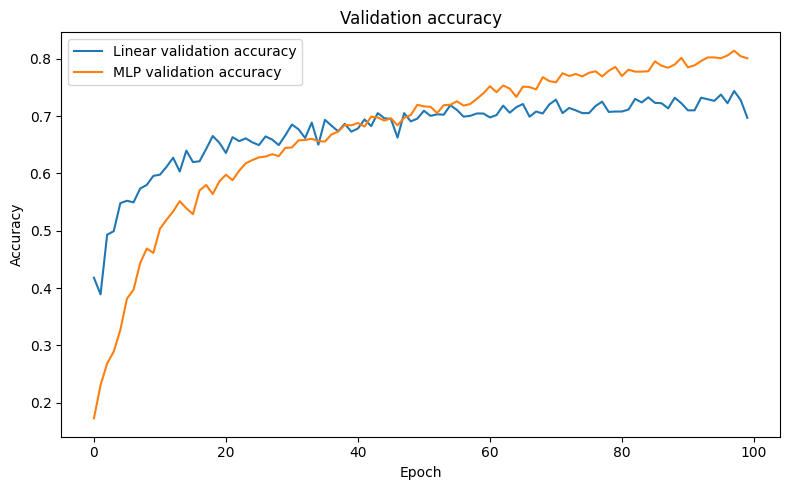

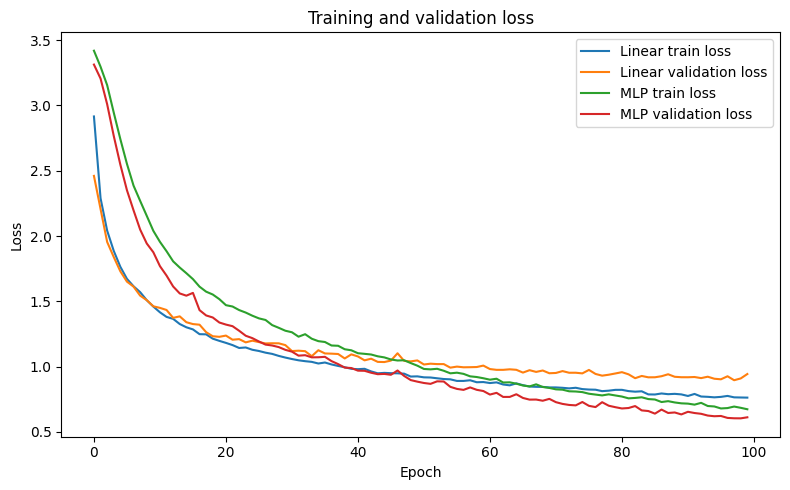

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(linear_history["val_accuracy"], label="Linear validation accuracy")
plt.plot(mlp_history["val_accuracy"], label="MLP validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(linear_history["train_loss"], label="Linear train loss")
plt.plot(linear_history["val_loss"], label="Linear validation loss")
plt.plot(mlp_history["train_loss"], label="MLP train loss")
plt.plot(mlp_history["val_loss"], label="MLP validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation loss")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Final test evaluation

In [14]:
linear_test_loss, linear_test_acc, linear_test_f1, linear_targets, linear_preds = evaluate(
    linear_model, test_loader, criterion, device
)
mlp_test_loss, mlp_test_acc, mlp_test_f1, mlp_targets, mlp_preds = evaluate(
    mlp_model, test_loader, criterion, device
)

results = pd.DataFrame([
    {"model": "Linear baseline", "test_loss": linear_test_loss, "test_accuracy": linear_test_acc, "test_macro_f1": linear_test_f1},
    {"model": "MLP", "test_loss": mlp_test_loss, "test_accuracy": mlp_test_acc, "test_macro_f1": mlp_test_f1},
])

results

,model,test_loss,test_accuracy,test_macro_f1
0,Linear baseline,0.985018,0.684573,0.569499
1,MLP,0.600546,0.797521,0.669821


In [15]:
print("MLP classification report:")
print(classification_report(mlp_targets, mlp_preds, target_names=[idx_to_label[i] for i in range(OUTPUT_SIZE)]))

MLP classification report:
              precision    recall  f1-score   support

           0       0.84      0.93      0.88        84
           1       0.60      0.56      0.58        16
           2       1.00      0.06      0.12        16
           3       0.71      0.59      0.65        17
           4       0.80      0.88      0.84        84
           5       0.79      0.65      0.71        17
           6       0.77      0.93      0.84        84
           7       0.71      0.59      0.65        17
           8       0.80      0.32      0.46        25
           9       0.78      0.98      0.87        84
           a       0.50      0.47      0.48        17
           b       0.93      0.93      0.93        42
           c       0.89      1.00      0.94        84
           d       0.63      0.68      0.65        25
           e       0.82      0.53      0.64        17
           f       0.86      0.71      0.77        17
           g       0.91      0.98      0.94        84


c:\Users\tobi\venvs\ml\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\tobi\venvs\ml\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\tobi\venvs\ml\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


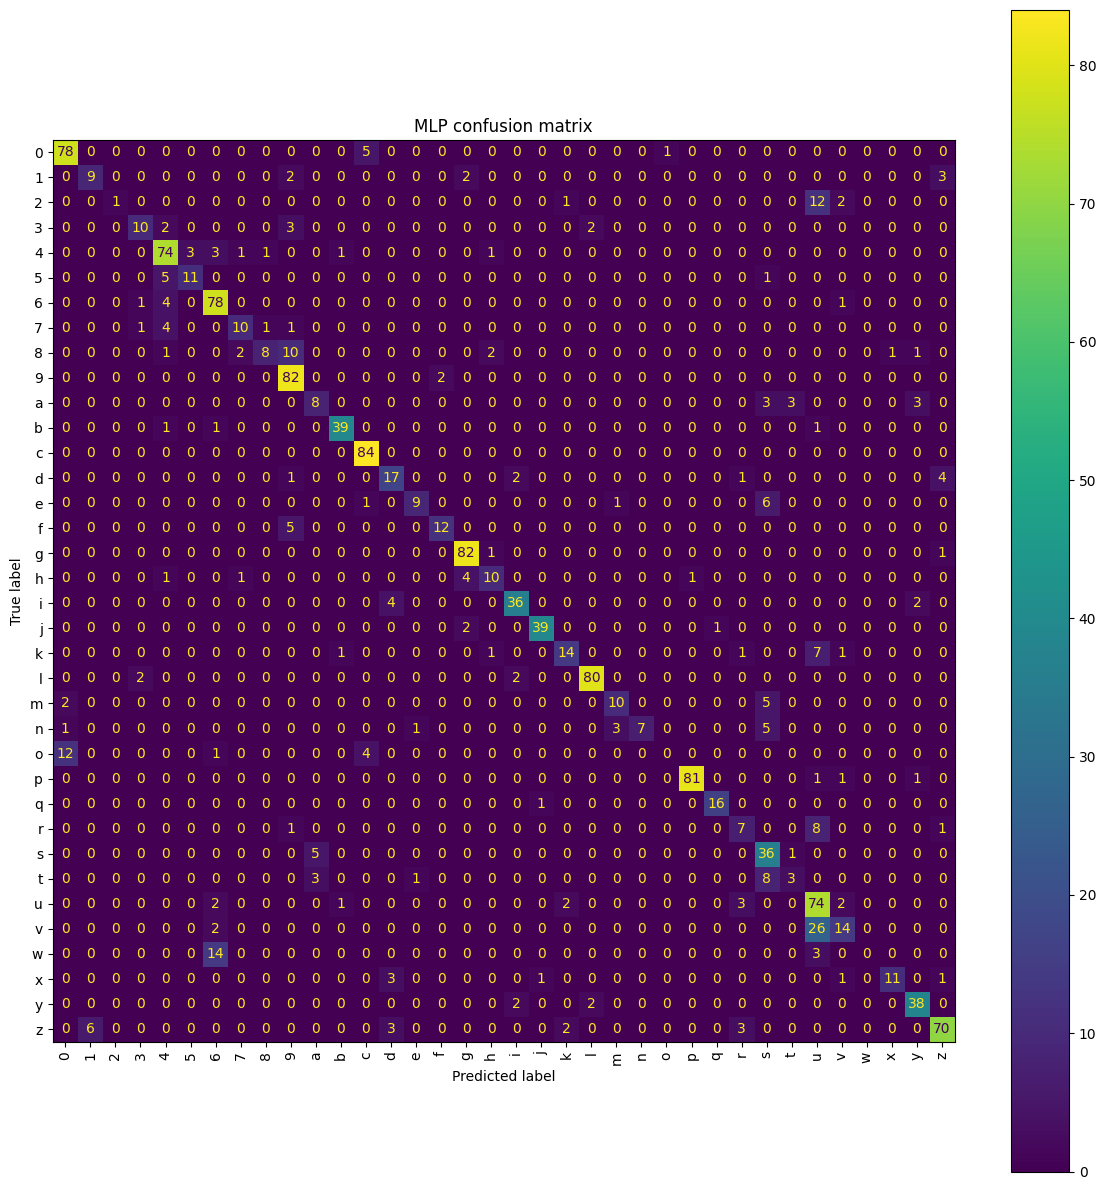

In [16]:
cm = confusion_matrix(mlp_targets, mlp_preds)
fig, ax = plt.subplots(figsize=(12, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[idx_to_label[i] for i in range(OUTPUT_SIZE)])
disp.plot(ax=ax, xticks_rotation=90, values_format="d")
plt.title("MLP confusion matrix")
plt.tight_layout()
plt.show()

## 11. Save and load the final model

The project instructions require that the model can be saved and loaded without retraining.

In [17]:
MODEL_DIR = PROJECT_ROOT / "saved_models"
MODEL_DIR.mkdir(exist_ok=True)
MODEL_PATH = MODEL_DIR / "mlp_sign_language.pt"

checkpoint = {
    "model_state_dict": mlp_model.state_dict(),
    "input_size": INPUT_SIZE,
    "hidden_size": HIDDEN_SIZE,
    "output_size": OUTPUT_SIZE,
    "image_size": IMAGE_SIZE,
    "label_to_idx": label_to_idx,
    "idx_to_label": idx_to_label,
}

torch.save(checkpoint, MODEL_PATH)
print("Saved model to:", MODEL_PATH)
print("Model file size in MB:", MODEL_PATH.stat().st_size / (1024 * 1024))

Saved model to: saved_models\mlp_sign_language.pt
Model file size in MB: 4.290844917297363


In [18]:
loaded_checkpoint = torch.load(MODEL_PATH, map_location=device)
loaded_model = Net(
    loaded_checkpoint["input_size"],
    loaded_checkpoint["hidden_size"],
    loaded_checkpoint["output_size"],
    dropout=0.3
).to(device)
loaded_model.load_state_dict(loaded_checkpoint["model_state_dict"])

loaded_test_loss, loaded_test_acc, loaded_test_f1, _, _ = evaluate(
    loaded_model, test_loader, criterion, device
)

print(f"Loaded model test accuracy: {loaded_test_acc:.4f}")
print(f"Loaded model test macro F1: {loaded_test_f1:.4f}")

Loaded model test accuracy: 0.7975
Loaded model test macro F1: 0.6698


## What changed compared to the course addendum?

- `datasets.MNIST` was replaced by `SignLanguageDataset`.
- `INPUT_SIZE` changed from `784` to `4096` because we resize to `64x64`.
- `OUTPUT_SIZE` changed from `10` to `36`.
- We keep `nn.CrossEntropyLoss()` because this is still single-label multiclass classification.
- We keep minibatch training with `DataLoader`.
- We added a validation split, macro F1-score, confusion matrix, and model saving/loading for the project requirements.
